In [1]:
# Exploratory Data Analysis (EDA)
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
DATA_DIR = Path("../data")
PROCESSED_DATA_PATH = DATA_DIR / "processed" / "sales_data_cleaned.csv"

OUTPUT_DIR = Path("../output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
sales_df = pd.read_csv(
    PROCESSED_DATA_PATH,
    parse_dates=["ORDERDATE"]
)

sales_df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,"2,871.00",2003-02-24,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,NaN,897 Long Airport Avenue,NaN,NYC,NY,NaN,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,"2,765.90",2003-05-07,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,NaN,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,"3,884.34",2003-07-01,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,NaN,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,"3,746.70",2003-08-25,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,NaN,78934 Hillside Dr.,NaN,Pasadena,CA,NaN,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,"5,205.27",2003-10-10,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,NaN,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [4]:
print(f"Rows    : {sales_df.shape[0]:,}")
print(f"Columns : {sales_df.shape[1]}")

Rows    : 2,823
Columns : 25


In [5]:
sales_df.info()

sales_df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDERNUMBER       2823 non-null   int64         
 1   QUANTITYORDERED   2823 non-null   int64         
 2   PRICEEACH         2823 non-null   float64       
 3   ORDERLINENUMBER   2823 non-null   int64         
 4   SALES             2823 non-null   float64       
 5   ORDERDATE         2823 non-null   datetime64[ns]
 6   STATUS            2823 non-null   object        
 7   QTR_ID            2823 non-null   int64         
 8   MONTH_ID          2823 non-null   int64         
 9   YEAR_ID           2823 non-null   int64         
 10  PRODUCTLINE       2823 non-null   object        
 11  MSRP              2823 non-null   int64         
 12  PRODUCTCODE       2823 non-null   object        
 13  CUSTOMERNAME      2823 non-null   object        
 14  PHONE             1819 n

,count,mean,min,25%,50%,75%,max,std
ORDERNUMBER,"2,823.00","10,258.73","10,100.00","10,180.00","10,262.00","10,333.50","10,425.00",92.09
QUANTITYORDERED,"2,823.00",35.09,6.00,27.00,35.00,43.00,97.00,9.74
PRICEEACH,"2,823.00",83.66,26.88,68.86,95.70,100.00,100.00,20.17
ORDERLINENUMBER,"2,823.00",6.47,1.00,3.00,6.00,9.00,18.00,4.23
SALES,"2,823.00","3,553.89",482.13,"2,203.43","3,184.80","4,508.00","14,082.80","1,841.87"
ORDERDATE,2823,2004-05-11 00:16:49.989373056,2003-01-06 00:00:00,2003-11-06 12:00:00,2004-06-15 00:00:00,2004-11-17 12:00:00,2005-05-31 00:00:00,NaN
QTR_ID,"2,823.00",2.72,1.00,2.00,3.00,4.00,4.00,1.20
MONTH_ID,"2,823.00",7.09,1.00,4.00,8.00,11.00,12.00,3.66
YEAR_ID,"2,823.00","2,003.82","2,003.00","2,003.00","2,004.00","2,004.00","2,005.00",0.70
MSRP,"2,823.00",100.72,33.00,68.00,99.00,124.00,214.00,40.19


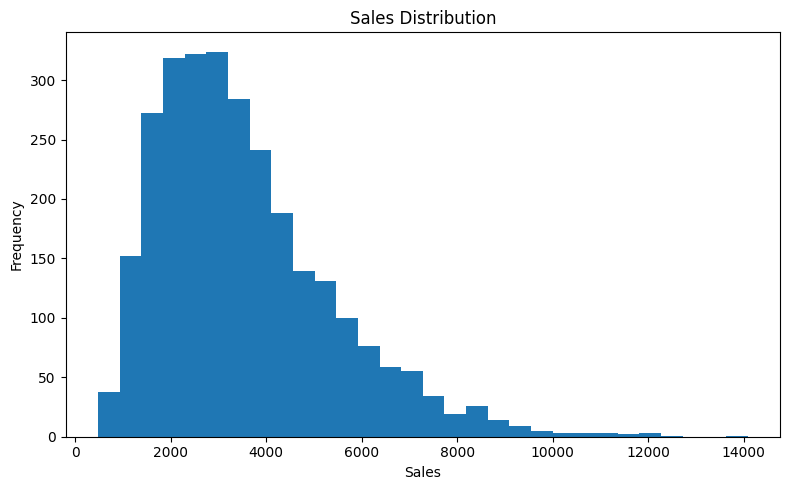

In [ ]:
# Sales Distribution
plt.figure(figsize=(8,5))

plt.hist(
    sales_df["SALES"],
    bins=30
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "sales_distribution.png",
    dpi=300
)

plt.show()

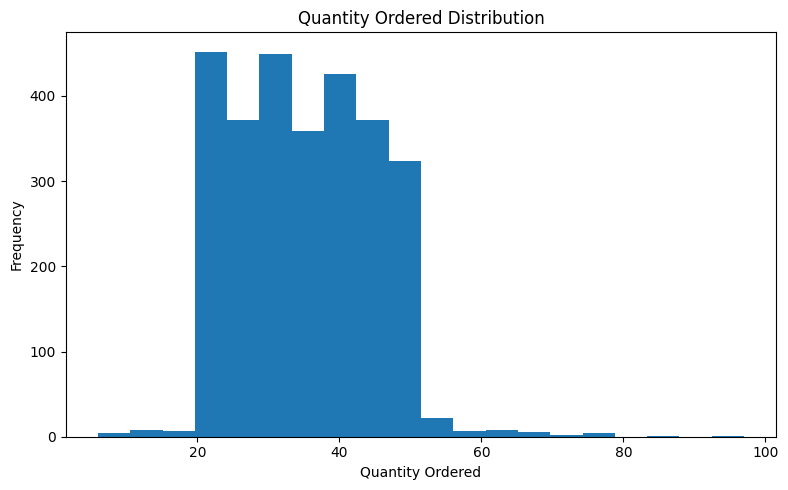

In [7]:
# Quantity Ordered Distribution
plt.figure(figsize=(8,5))

plt.hist(
    sales_df["QUANTITYORDERED"],
    bins=20
)

plt.title("Quantity Ordered Distribution")
plt.xlabel("Quantity Ordered")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "quantity_distribution.png",
    dpi=300
)

plt.show()

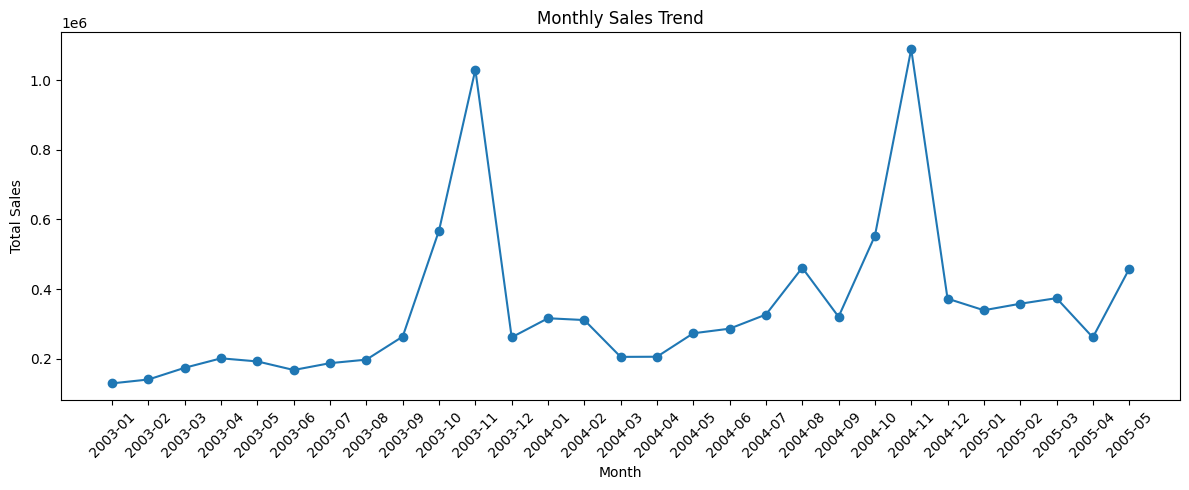

In [9]:
# Monthly Sales Index
monthly_sales = (
    sales_df
    .groupby(
        sales_df["ORDERDATE"].dt.to_period("M")
    )["SALES"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

monthly_sales

# Visualization
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "monthly_sales.png",
    dpi=300
)

plt.show()

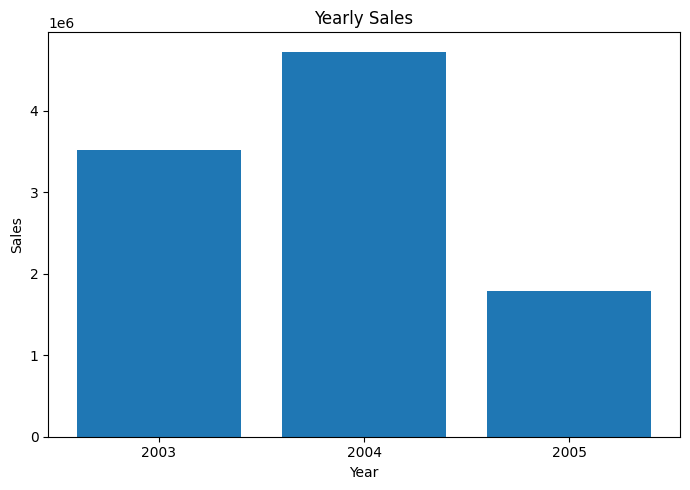

In [10]:
# Yearly Sales
yearly_sales = (
    sales_df
    .groupby("YEAR_ID")["SALES"]
    .sum()
    .sort_index()
)

yearly_sales

# Visualization
plt.figure(figsize=(7,5))

plt.bar(
    yearly_sales.index.astype(str),
    yearly_sales.values
)

plt.title("Yearly Sales")

plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "yearly_sales.png",
    dpi=300
)

plt.show()

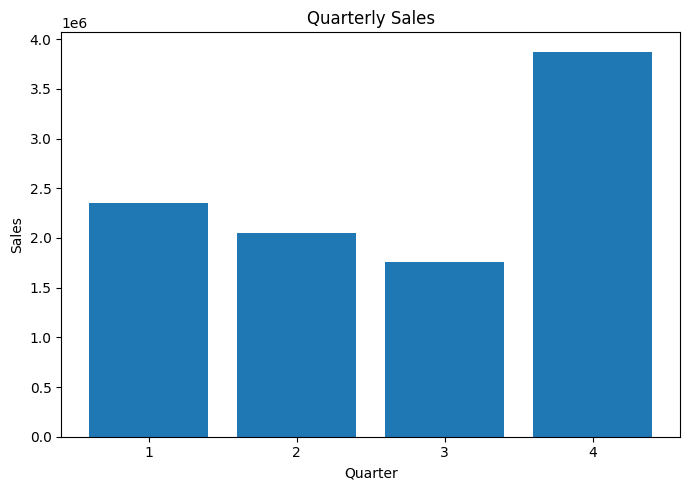

In [11]:
# Quarter Sales
quarter_sales = (
    sales_df
    .groupby("QTR_ID")["SALES"]
    .sum()
)

quarter_sales

# Visualization

plt.figure(figsize=(7,5))

plt.bar(
    quarter_sales.index.astype(str),
    quarter_sales.values
)

plt.title("Quarterly Sales")

plt.xlabel("Quarter")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "quarterly_sales.png",
    dpi=300
)

plt.show()

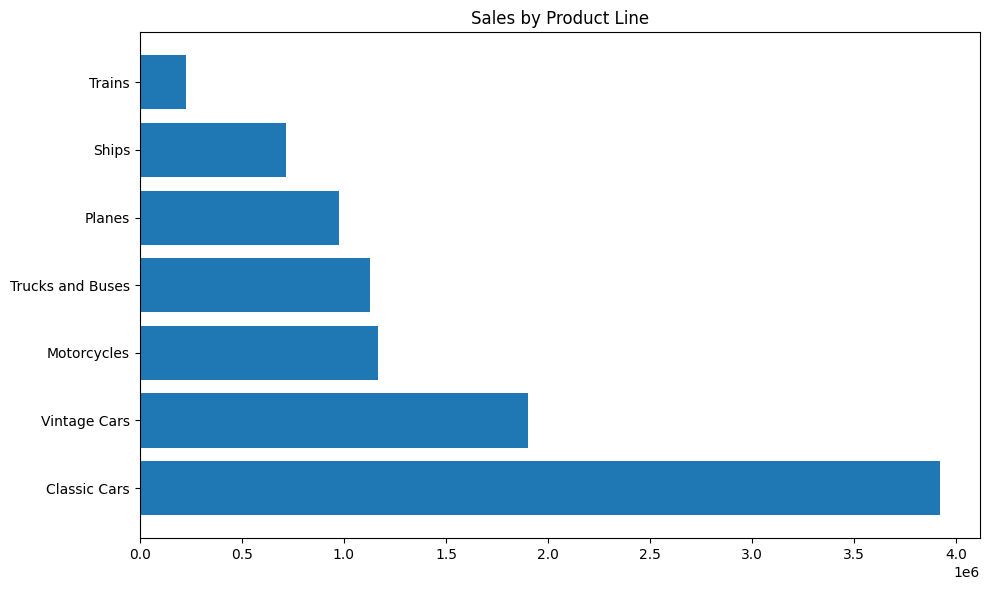

In [12]:
# Sales by Product Line
product_sales = (
    sales_df
    .groupby("PRODUCTLINE")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

product_sales

# Visualization
plt.figure(figsize=(10,6))

plt.barh(
    product_sales.index,
    product_sales.values
)

plt.title("Sales by Product Line")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "sales_productline.png",
    dpi=300
)

plt.show()

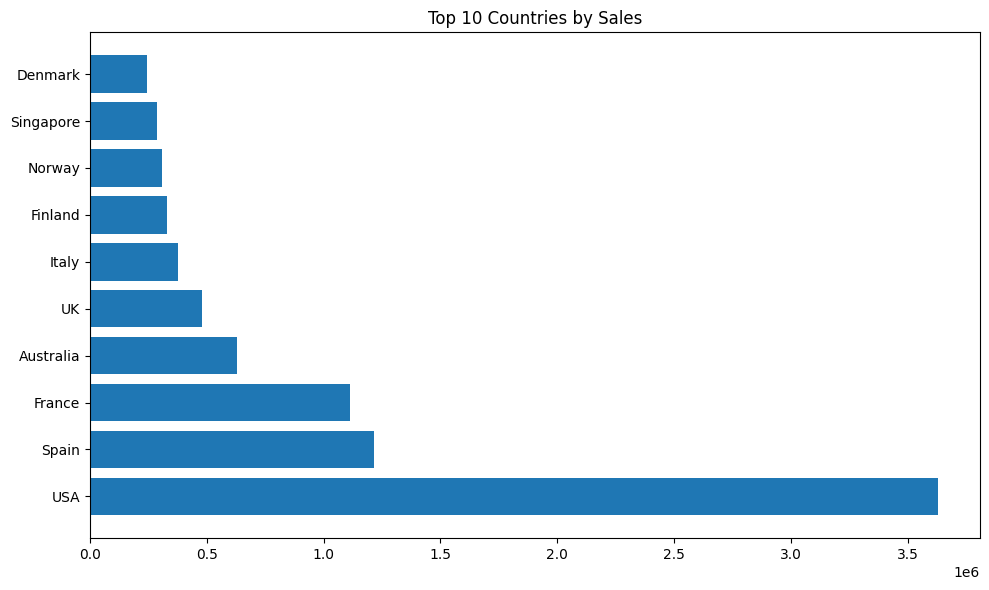

In [13]:
# Sales by Country
country_sales = (
    sales_df
    .groupby("COUNTRY")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

country_sales.head(10)

# Visualization
top_country = country_sales.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_country.index,
    top_country.values
)

plt.title("Top 10 Countries by Sales")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "country_sales.png",
    dpi=300
)

plt.show()

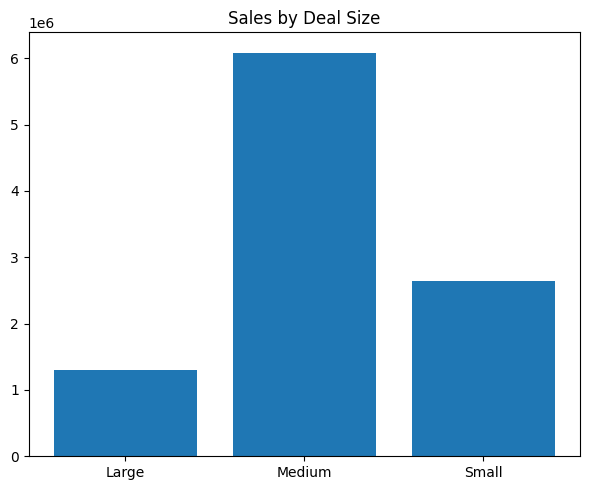

In [15]:
# Sales by Teritory
territory_sales = (
    sales_df
    .groupby("TERRITORY")["SALES"]
    .sum()
    .sort_values(ascending=False)
)

territory_sales

# Sales by Deal Size
deal_sales = (
    sales_df
    .groupby("DEALSIZE")["SALES"]
    .sum()
)

deal_sales


# Visualization
plt.figure(figsize=(6,5))

plt.bar(
    deal_sales.index,
    deal_sales.values
)

plt.title("Sales by Deal Size")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "deal_size_sales.png",
    dpi=300
)

plt.show()

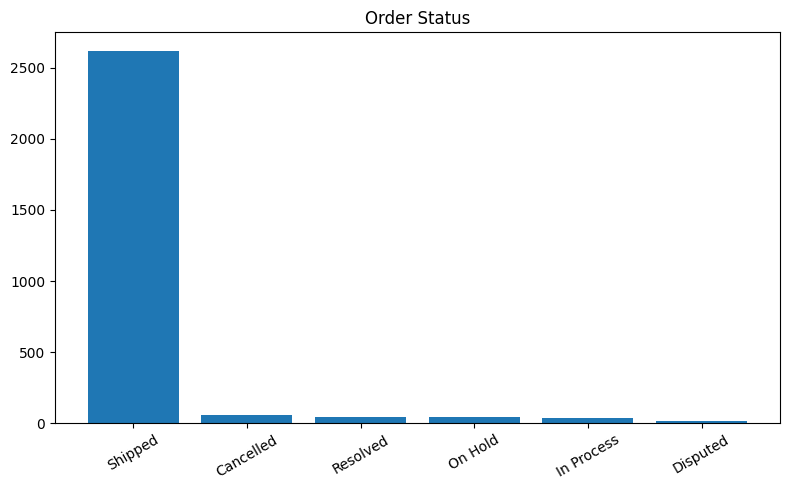

In [16]:
# Order Status
status_count = sales_df["STATUS"].value_counts()

status_count

plt.figure(figsize=(8,5))

plt.bar(
    status_count.index,
    status_count.values
)

plt.title("Order Status")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "order_status.png",
    dpi=300
)

plt.show()

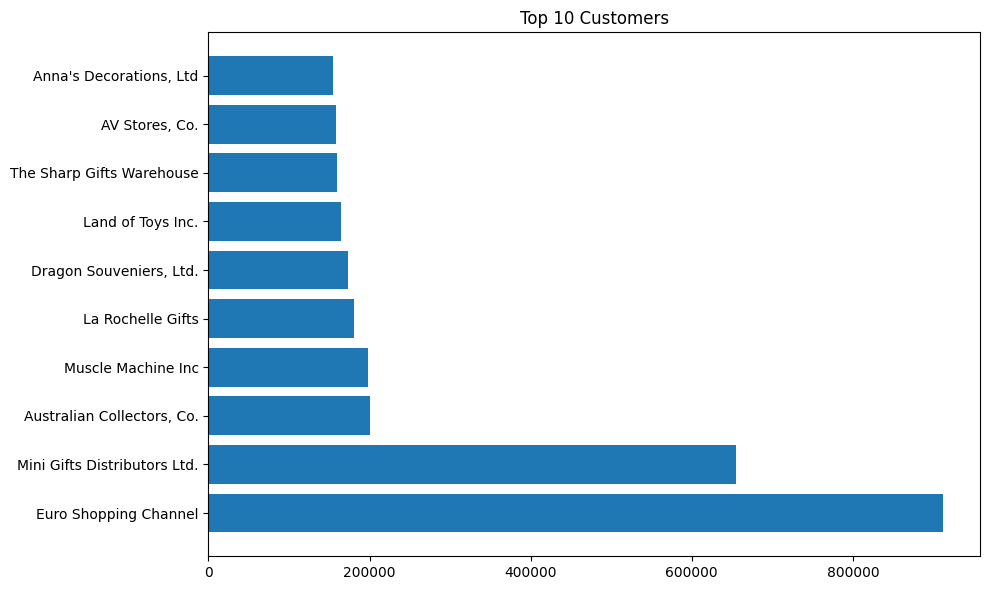

In [17]:
# Top 10 Customers
top_customers = (
    sales_df
    .groupby("CUSTOMERNAME")["SALES"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

plt.figure(figsize=(10,6))

plt.barh(
    top_customers.index,
    top_customers.values
)

plt.title("Top 10 Customers")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "top_customers.png",
    dpi=300
)

plt.show()

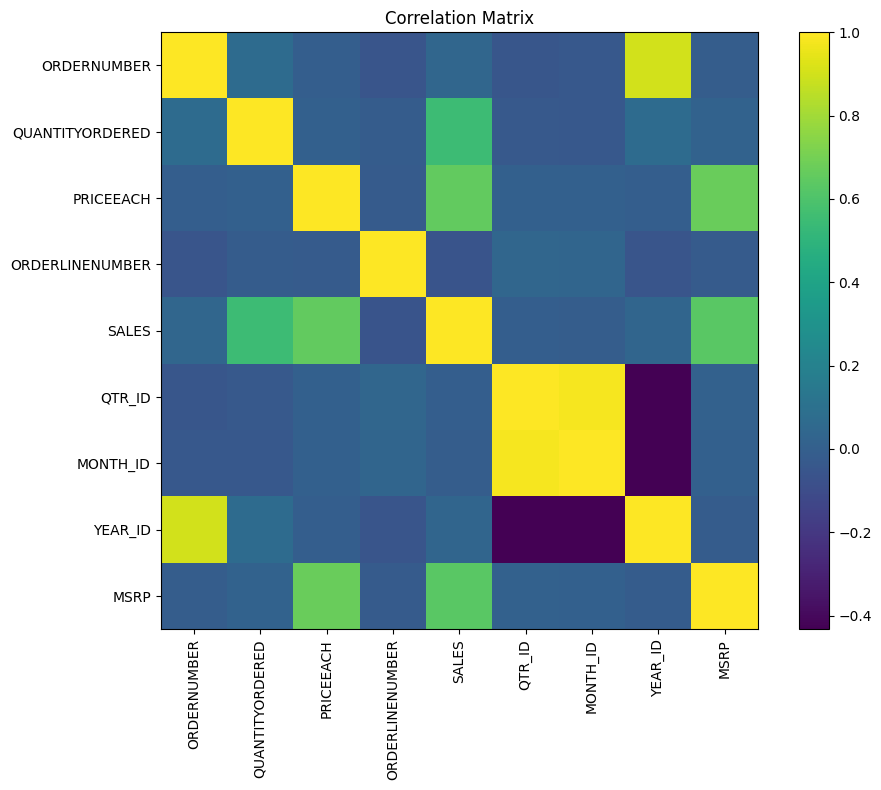

In [18]:
# Correlation Analysis
correlation = sales_df.select_dtypes("number").corr()

correlation

plt.figure(figsize=(10,8))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "correlation_matrix.png",
    dpi=300
)

plt.show()